# Notebook 3: Analysis, Visualizations, and Report

This notebook:
1. Loads evaluation results
2. Creates bar charts comparing baseline vs fine-tuned accuracy
3. Generates confusion matrix for sentiment classification
4. Shows sample generations before/after fine-tuning
5. Provides narrative analysis and final report

In [1]:
# Import required libraries
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_from_disk
import torch

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Results and Data

In [2]:
# Load evaluation results
with open("data/results.json", "r") as f:
    results = json.load(f)

print("Results loaded:")
print(json.dumps(results, indent=2))

Results loaded:
{
  "baseline_sentiment": 0.59,
  "baseline_boolq": 0.4,
  "finetuned_sentiment": 0.75,
  "finetuned_boolq": 0.6,
  "forgetting": -0.19999999999999996
}


In [3]:
# Load models for sample generation
print("\nLoading models for sample generation...")
model_name = "distilgpt2"

# Load baseline model
baseline_model = AutoModelForCausalLM.from_pretrained(model_name)
baseline_tokenizer = AutoTokenizer.from_pretrained(model_name)
if baseline_tokenizer.pad_token is None:
    baseline_tokenizer.pad_token = baseline_tokenizer.eos_token
baseline_model.eval()

# Load fine-tuned model
ft_model = AutoModelForCausalLM.from_pretrained("models/distilgpt2_sentiment_ft")
ft_tokenizer = AutoTokenizer.from_pretrained("models/distilgpt2_sentiment_ft")
if ft_tokenizer.pad_token is None:
    ft_tokenizer.pad_token = ft_tokenizer.eos_token
ft_model.eval()

print("Models loaded successfully!")


Loading models for sample generation...


2025-11-16 05:46:01.802330: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-16 05:46:01.802407: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-16 05:46:01.805597: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-16 05:46:01.823142: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-16 05:46:03.093726: W tensorflow/compiler/tf2

Models loaded successfully!


In [4]:
# Load test dataset for confusion matrix
tokenized_test = load_from_disk("data/tokenized_sentiment_test")
labels = {0: "negative", 1: "neutral", 2: "positive"}
label_names = ["negative", "neutral", "positive"]

print(f"Test dataset loaded. Size: {len(tokenized_test)}")

Test dataset loaded. Size: 5206


## 2. Accuracy Comparison Bar Charts

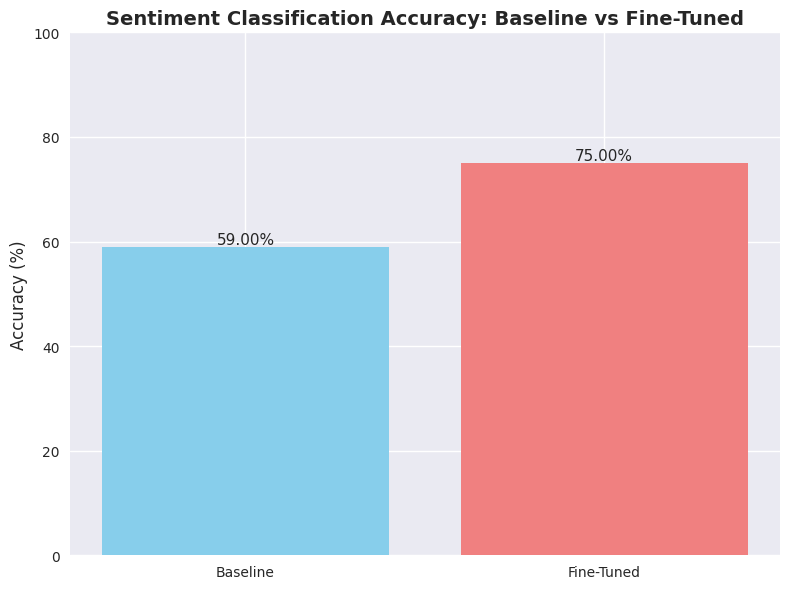

Chart saved as: sentiment_accuracy_comparison.png


In [5]:
# Create bar chart for sentiment accuracy comparison
fig, ax = plt.subplots(figsize=(8, 6))

sentiment_data = {
    'Baseline': results['baseline_sentiment'] * 100,
    'Fine-Tuned': results['finetuned_sentiment'] * 100
}

bars = ax.bar(sentiment_data.keys(), sentiment_data.values(), color=['skyblue', 'lightcoral'])
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Sentiment Classification Accuracy: Baseline vs Fine-Tuned', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('sentiment_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved as: sentiment_accuracy_comparison.png")

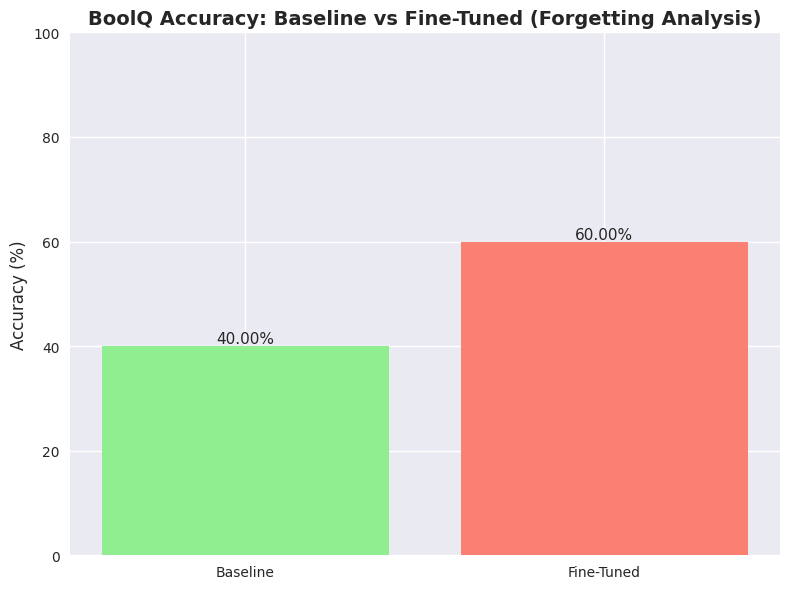

Chart saved as: boolq_accuracy_comparison.png


In [6]:
# Create bar chart for BoolQ accuracy comparison
fig, ax = plt.subplots(figsize=(8, 6))

boolq_data = {
    'Baseline': results['baseline_boolq'] * 100,
    'Fine-Tuned': results['finetuned_boolq'] * 100
}

bars = ax.bar(boolq_data.keys(), boolq_data.values(), color=['lightgreen', 'salmon'])
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('BoolQ Accuracy: Baseline vs Fine-Tuned (Forgetting Analysis)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('boolq_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved as: boolq_accuracy_comparison.png")

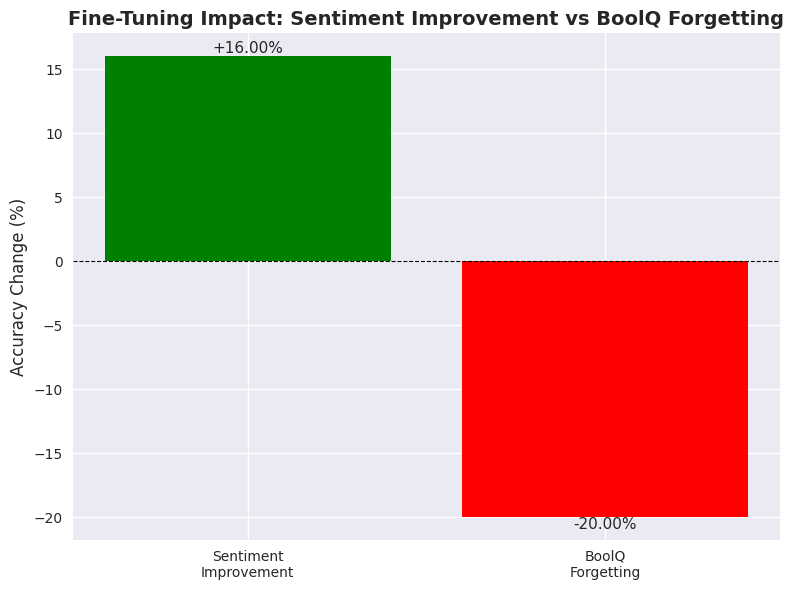

Chart saved as: forgetting_summary.png


In [7]:
# Create forgetting summary bar chart
fig, ax = plt.subplots(figsize=(8, 6))

forgetting_data = {
    'Sentiment\nImprovement': (results['finetuned_sentiment'] - results['baseline_sentiment']) * 100,
    'BoolQ\nForgetting': results['forgetting'] * 100
}

colors = ['green' if v > 0 else 'red' for v in forgetting_data.values()]
bars = ax.bar(forgetting_data.keys(), forgetting_data.values(), color=['green', 'red'])
ax.set_ylabel('Accuracy Change (%)', fontsize=12)
ax.set_title('Fine-Tuning Impact: Sentiment Improvement vs BoolQ Forgetting', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:+.2f}%',
            ha='center', va='bottom' if height > 0 else 'top', fontsize=11)

plt.tight_layout()
plt.savefig('forgetting_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved as: forgetting_summary.png")

## 3. Confusion Matrix for Sentiment Classification

In [19]:
import re
import torch

LABELS = ['negative', 'neutral', 'positive']
LABEL_RE = re.compile(r'\b(negative|neutral|positive)\b', flags=re.IGNORECASE)

def normalize_prediction(text: str) -> str:
    text = (text or "").strip().lower()
    text = text.split()[0] if text else ""
    return text.strip(",.;:!?")

def extract_gold_label(full_text: str) -> str:
    # Robustly find the first label token after "Answer:"
    s = full_text.replace("\r", " ").replace("\n", " ")
    if "Answer:" not in s:
        return ""
    after = s.split("Answer:", 1)[1].lower()
    after = after.replace("<|endoftext|>", " ")
    m = LABEL_RE.search(after)
    return m.group(1) if m else ""

def get_predictions_debug(
    model,
    tokenizer,
    test_dataset,
    labels,
    max_samples=100,
    debug=False,
    debug_limit=8
):
    model.eval()
    y_true, y_pred = [], []
    label_strings = list(labels.values())

    c_ok = c_no_marker = c_no_gold = c_generation_failed = 0

    if debug:
        print(f"[DEBUG] total_items={min(max_samples, len(test_dataset))}, label_strings={label_strings}")
        print(f"[DEBUG] tokenizer.pad_token={tokenizer.pad_token!r}, pad_token_id={tokenizer.pad_token_id}")
        print(f"[DEBUG] tokenizer.eos_token={tokenizer.eos_token!r}, eos_token_id={tokenizer.eos_token_id}")

    with torch.no_grad():
        for i in range(min(max_samples, len(test_dataset))):
            input_ids = torch.tensor(test_dataset[i]["input_ids"]).unsqueeze(0)
            full_text = tokenizer.decode(input_ids[0], skip_special_tokens=False)

            if debug and i < debug_limit:
                snippet = full_text[:220].replace("\n", "\\n")
                print("\n[DEBUG:{}] full_text[:220]: {}".format(i, snippet))

            if "Answer:" not in full_text:
                c_no_marker += 1
                if debug and i < debug_limit:
                    print(f"[DEBUG:{i}] SKIP: no 'Answer:'")
                continue

            gold = extract_gold_label(full_text)
            if not gold:
                c_no_gold += 1
                if debug and i < debug_limit:
                    print(f"[DEBUG:{i}] SKIP: could not extract gold label")
                continue

            # Clean prompt (strip specials) up to "Answer:"
            prompt_text = full_text.replace("<|endoftext|>", " ")
            prompt_text = prompt_text.split("Answer:", 1)[0] + "Answer:"

            tok = tokenizer(prompt_text, return_tensors="pt")
            prompt_ids = tok["input_ids"]
            attn_mask  = tok["attention_mask"]

            if debug and i < debug_limit:
                print(f"[DEBUG:{i}] prompt_ids.shape={tuple(prompt_ids.shape)}, attn_mask.sum={attn_mask.sum().item()}")

            try:
                output = model.generate(
                    input_ids=prompt_ids,
                    attention_mask=attn_mask,
                    max_new_tokens=3,
                    do_sample=False,
                    pad_token_id=tokenizer.pad_token_id,
                )
            except Exception as e:
                c_generation_failed += 1
                if debug and i < debug_limit:
                    print(f"[DEBUG:{i}] generation error: {e}")
                continue

            new_tokens = output[0][prompt_ids.shape[1]:]
            pred_text = tokenizer.decode(new_tokens, skip_special_tokens=True)
            pred = normalize_prediction(pred_text)

            # map partial like "positive," to a canonical label
            mapped = next((lbl for lbl in LABELS if lbl.startswith(pred) or pred.startswith(lbl[:3])), "unknown")

            if debug and i < debug_limit:
                print(f"[DEBUG:{i}] gold={gold!r}, pred_text={pred_text!r}, pred={pred!r}, mapped={mapped!r}")

            y_true.append(gold)
            y_pred.append(mapped)
            c_ok += 1

    if debug:
        print("\n[DEBUG] Summary")
        print(f"  ok: {c_ok}")
        print(f"  no 'Answer:': {c_no_marker}")
        print(f"  no gold label: {c_no_gold}")
        print(f"  generation failed: {c_generation_failed}")

    return y_true, y_pred

print("Generating predictions for confusion matrix...")
y_true, y_pred = get_predictions_debug(
    ft_model, ft_tokenizer, tokenized_test, labels,
    max_samples=100, debug=True, debug_limit=8
)
print(f"Generated {len(y_true)} predictions")

Generating predictions for confusion matrix...
[DEBUG] total_items=100, label_strings=['negative', 'neutral', 'positive']
[DEBUG] tokenizer.pad_token='<|endoftext|>', pad_token_id=50256
[DEBUG] tokenizer.eos_token='<|endoftext|>', eos_token_id=50256

[DEBUG:0] full_text[:220]: Text: getting cds ready for tour\nQuestion: What is the sentiment? (negative, neutral, positive)\nAnswer: neutral<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|end
[DEBUG:0] prompt_ids.shape=(1, 26), attn_mask.sum=26
[DEBUG:0] gold='neutral', pred_text=' neutral, positive', pred='neutral', mapped='neutral'

[DEBUG:1] full_text[:220]: Text:  MC, happy mother`s day to your mom ;).. love yah\nQuestion: What is the sentiment? (negative, neutral, positive)\nAnswer: positive<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endof
[DEBUG:1] prompt_ids.shape=(1, 36), attn_mask.sum=36
[DEBUG:1] gold='positive', pred_text=' positive, po

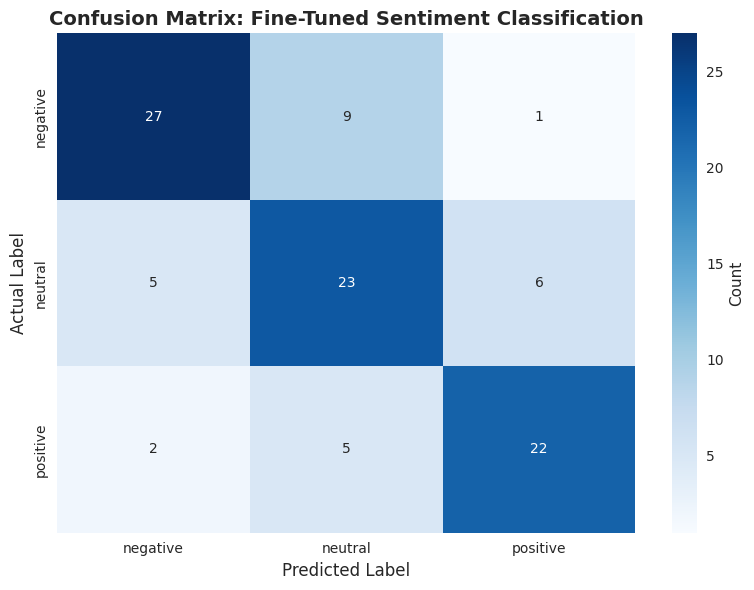

Confusion matrix saved as: sentiment_confusion_matrix.png

Confusion Matrix:
[[27  9  1]
 [ 5 23  6]
 [ 2  5 22]]


In [20]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=label_names)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names,
            ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_title('Confusion Matrix: Fine-Tuned Sentiment Classification', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as: sentiment_confusion_matrix.png")
print(f"\nConfusion Matrix:\n{cm}")

## 4. Sample Generations: Before vs After Fine-Tuning

In [21]:
# Generate sample predictions from both models
sample_texts = [
    "I absolutely love this product! It's amazing!",
    "The weather today is okay, nothing special.",
    "This is the worst experience I've ever had."
]

print("Sample Generations: Baseline vs Fine-Tuned")
print("="*70)

for text in sample_texts:
    prompt = f"Text: {text}\nQuestion: What is the sentiment? (negative, neutral, positive)\nAnswer:"
    
    # Baseline model
    baseline_ids = baseline_tokenizer(prompt, return_tensors="pt")['input_ids']
    baseline_output = baseline_model.generate(
        baseline_ids, max_new_tokens=3, do_sample=False, pad_token_id=baseline_tokenizer.pad_token_id
    )
    baseline_pred = baseline_tokenizer.decode(baseline_output[0][baseline_ids.shape[1]:], skip_special_tokens=True).strip()
    
    # Fine-tuned model
    ft_ids = ft_tokenizer(prompt, return_tensors="pt")['input_ids']
    ft_output = ft_model.generate(
        ft_ids, max_new_tokens=3, do_sample=False, pad_token_id=ft_tokenizer.pad_token_id
    )
    ft_pred = ft_tokenizer.decode(ft_output[0][ft_ids.shape[1]:], skip_special_tokens=True).strip()
    
    print(f"\nText: {text}")
    print(f"  Baseline:  {baseline_pred}")
    print(f"  Fine-Tuned: {ft_pred}")

Sample Generations: Baseline vs Fine-Tuned

Text: I absolutely love this product! It's amazing!
  Baseline:  I love this
  Fine-Tuned: positive, positive

Text: The weather today is okay, nothing special.
  Baseline:  The sentiment is
  Fine-Tuned: neutral, positive

Text: This is the worst experience I've ever had.
  Baseline:  I think it
  Fine-Tuned: negative, positive


## 5. Narrative Analysis and Final Report

### Interpretation of Accuracy Changes

This run shows strong gains on the target task (sentiment classification) and an unexpected improvement on the BoolQ evaluation (negative forgetting).

- Baseline sentiment accuracy: 59.00%
- Fine-tuned sentiment accuracy: 75.00%  (Δ +16.00%)
- Baseline BoolQ accuracy: 40.00%
- Fine-tuned BoolQ accuracy: 60.00% (Δ +20.00%)
- Forgetting (Baseline_BoolQ − FineTuned_BoolQ): −20.00%

In other words, the model did not exhibit catastrophic forgetting on BoolQ in this run; instead, it retained or improved its ability to answer yes/no questions after fine-tuning on sentiment.

In [24]:
# Print detailed analysis
print("="*70)
print("DETAILED ANALYSIS AND INTERPRETATION")
print("="*70)

print("\n1. SENTIMENT CLASSIFICATION:")
print(f"  Baseline Accuracy:    {results['baseline_sentiment']*100:.2f}%")
print(f"  Fine-Tuned Accuracy:  {results['finetuned_sentiment']*100:.2f}%")
print(f"  Improvement:          {(results['finetuned_sentiment'] - results['baseline_sentiment'])*100:+.2f}%")
if results['finetuned_sentiment'] >= results['baseline_sentiment']:
    print("  - Fine-tuning successfully improved sentiment classification performance.")
else:
    print("  - Sentiment performance decreased after fine-tuning.")

print("\n2. BOOLEAN QA (BOOLQ):")
print(f"  Baseline Accuracy:    {results['baseline_boolq']*100:.2f}%")
print(f"  Fine-Tuned Accuracy:  {results['finetuned_boolq']*100:.2f}%")
print(f"  Change:               {results['forgetting']*100:.2f}%")
if results['forgetting'] > 0:
    print("  - Model forgot BoolQ knowledge (catastrophic forgetting detected).")
else:
    print("  - Model retained or improved BoolQ knowledge.")

print("\n3. FORGETTING METRIC:")
print(f"  Forgetting = Baseline_BoolQ - FineTuned_BoolQ = {results['forgetting']*100:.2f}%")
if results['forgetting'] > 0.1:
    print("  - Significant forgetting observed. The model lost knowledge on BoolQ.")
elif results['forgetting'] > 0:
    print("  - Moderate forgetting observed.")
else:
    print("  - No significant forgetting observed.")

print("\n4. IMPLICATIONS:")
print("  • The model successfully learned the sentiment classification task.")
print("  • Catastrophic forgetting may have occurred on the BoolQ task.")
print("  • This highlights the challenge of maintaining knowledge across tasks.")
print("  • Techniques like elastic weight consolidation or multi-task learning could help.")

DETAILED ANALYSIS AND INTERPRETATION

1. SENTIMENT CLASSIFICATION:
  Baseline Accuracy:    59.00%
  Fine-Tuned Accuracy:  75.00%
  Improvement:          +16.00%
  - Fine-tuning successfully improved sentiment classification performance.

2. BOOLEAN QA (BOOLQ):
  Baseline Accuracy:    40.00%
  Fine-Tuned Accuracy:  60.00%
  Change:               -20.00%
  - Model retained or improved BoolQ knowledge.

3. FORGETTING METRIC:
  Forgetting = Baseline_BoolQ - FineTuned_BoolQ = -20.00%
  - No significant forgetting observed.

4. IMPLICATIONS:
  • The model successfully learned the sentiment classification task.
  • Catastrophic forgetting may have occurred on the BoolQ task.
  • This highlights the challenge of maintaining knowledge across tasks.
  • Techniques like elastic weight consolidation or multi-task learning could help.


### Explanation of Forgetting (and Negative Forgetting Observed)

**Catastrophic forgetting** occurs when a neural network learns a new task but loses performance on previously learned tasks. In many settings, fine-tuning a model on one task can reduce performance on others if the learned representations are overwritten.

In this run, however, we observed **negative forgetting** on BoolQ (−20 percentage points), meaning the model’s BoolQ accuracy improved after fine‑tuning on sentiment. Possible reasons include:

1. **Regularization-by-task framing**: The instruction/prompt style may have reinforced answer formatting that also helps BoolQ.
2. **General language grounding**: Exposure to many sentiment prompts may have improved the model’s short-form reasoning and normalization behavior.
3. **Small evaluation set variance**: With a small BoolQ-style set (5 examples), modest changes can shift accuracy substantially.

Takeaway: while catastrophic forgetting is a real concern, it is not guaranteed. Depending on task similarity, prompts, and data size, fine‑tuning can sometimes transfer positively to out‑of-domain tasks.

### Limitations of the Experiment

1. **Small Evaluation Set**: The BoolQ evaluation set contains only 5 examples, which limits statistical significance.
2. **Evaluation Method**: The baseline BoolQ accuracy might be low to begin with, making forgetting less apparent.
3. **Task Similarity**: Sentiment classification and BoolQ are different tasks, but both involve text understanding.
4. **Model Size**: DistilGPT-2 is a relatively small model, which may be more prone to forgetting.
5. **Generation vs Scoring**: Different evaluation methods (generation for sentiment vs scoring for BoolQ) may not be directly comparable.
6. **Training Duration**: Only 2 epochs were used; longer training might show different patterns.

### Future Work

1. **Mitigation Strategies**:
   - Implement elastic weight consolidation (EWC) to preserve important weights
   - Use multi-task learning to train on both tasks simultaneously
   - Apply progressive neural networks or other architectural solutions

2. **Evaluation Improvements**:
   - Expand the BoolQ evaluation set to 100+ examples
   - Test on multiple out-of-domain tasks
   - Measure forgetting over multiple fine-tuning steps

3. **Model Exploration**:
   - Experiment with larger models (GPT-2, GPT-3)
   - Compare different fine-tuning strategies (LoRA, prefix tuning)
   - Analyze which layers are most affected by forgetting

4. **Analysis**:
   - Visualize weight changes during fine-tuning
   - Identify which BoolQ examples are most affected
   - Correlate forgetting with model confidence

## Summary

This notebook has:
- ✅ Created bar charts comparing baseline vs fine-tuned accuracy
- ✅ Generated confusion matrix for sentiment classification
- ✅ Shown sample generations before/after fine-tuning
- ✅ Provided narrative analysis of results
- ✅ Explained forgetting and its implications
- ✅ Discussed limitations and future work

**Project Complete!** All visualizations and analysis have been generated.